Loading data...
Creating visualizations...


C:\Users\Aelina.Daniiarkyzy\AppData\Local\Temp\ipykernel_11836\2564437617.py:143: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  elevation_flood = df.groupby(elevation_bins)['flood_status'].mean() * 100
C:\Users\Aelina.Daniiarkyzy\AppData\Local\Temp\ipykernel_11836\2564437617.py:154: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  soil_moisture_flood = df.groupby(soil_moisture_bins)['flood_status'].mean() * 100
C:\Users\Aelina.Daniiarkyzy\AppData\Local\Temp\ipykernel_11836\2564437617.py:281: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; sup

Visualizations complete! All plots saved to 'visualizations' directory.


<Figure size 1400x1000 with 0 Axes>

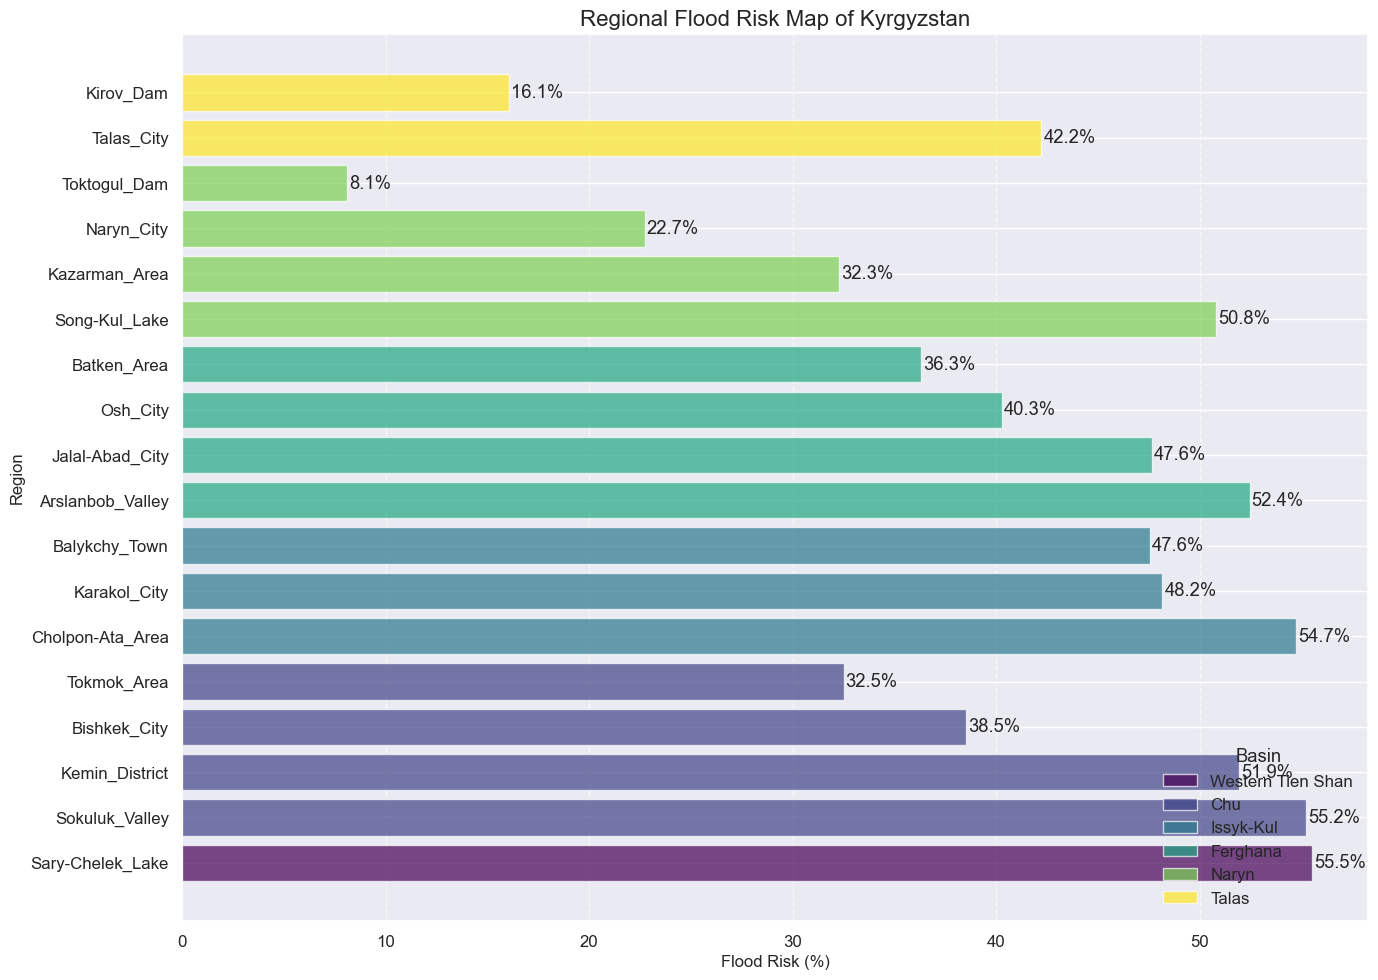

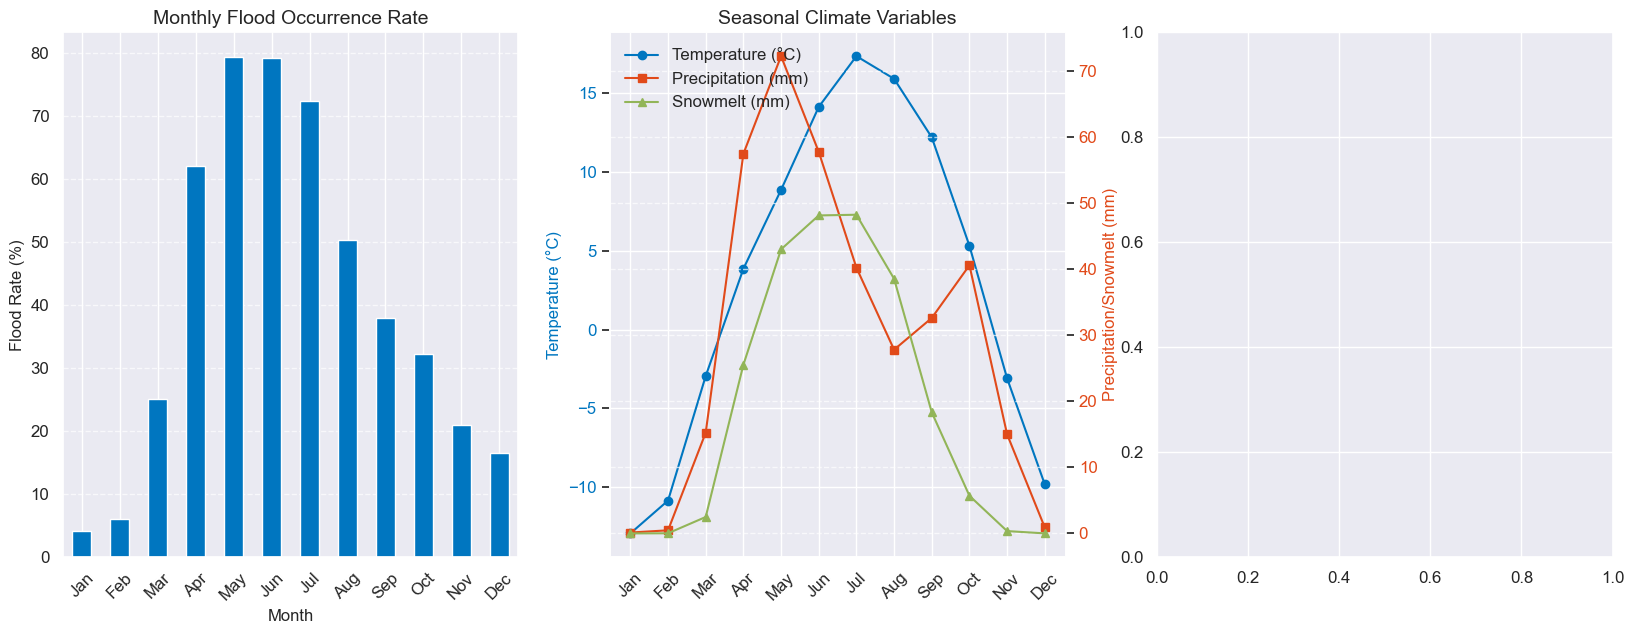

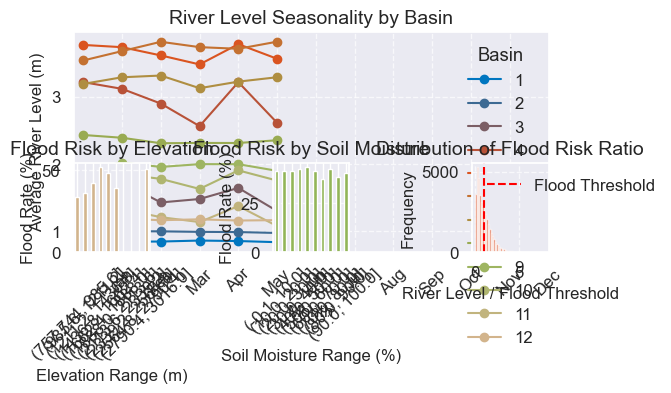

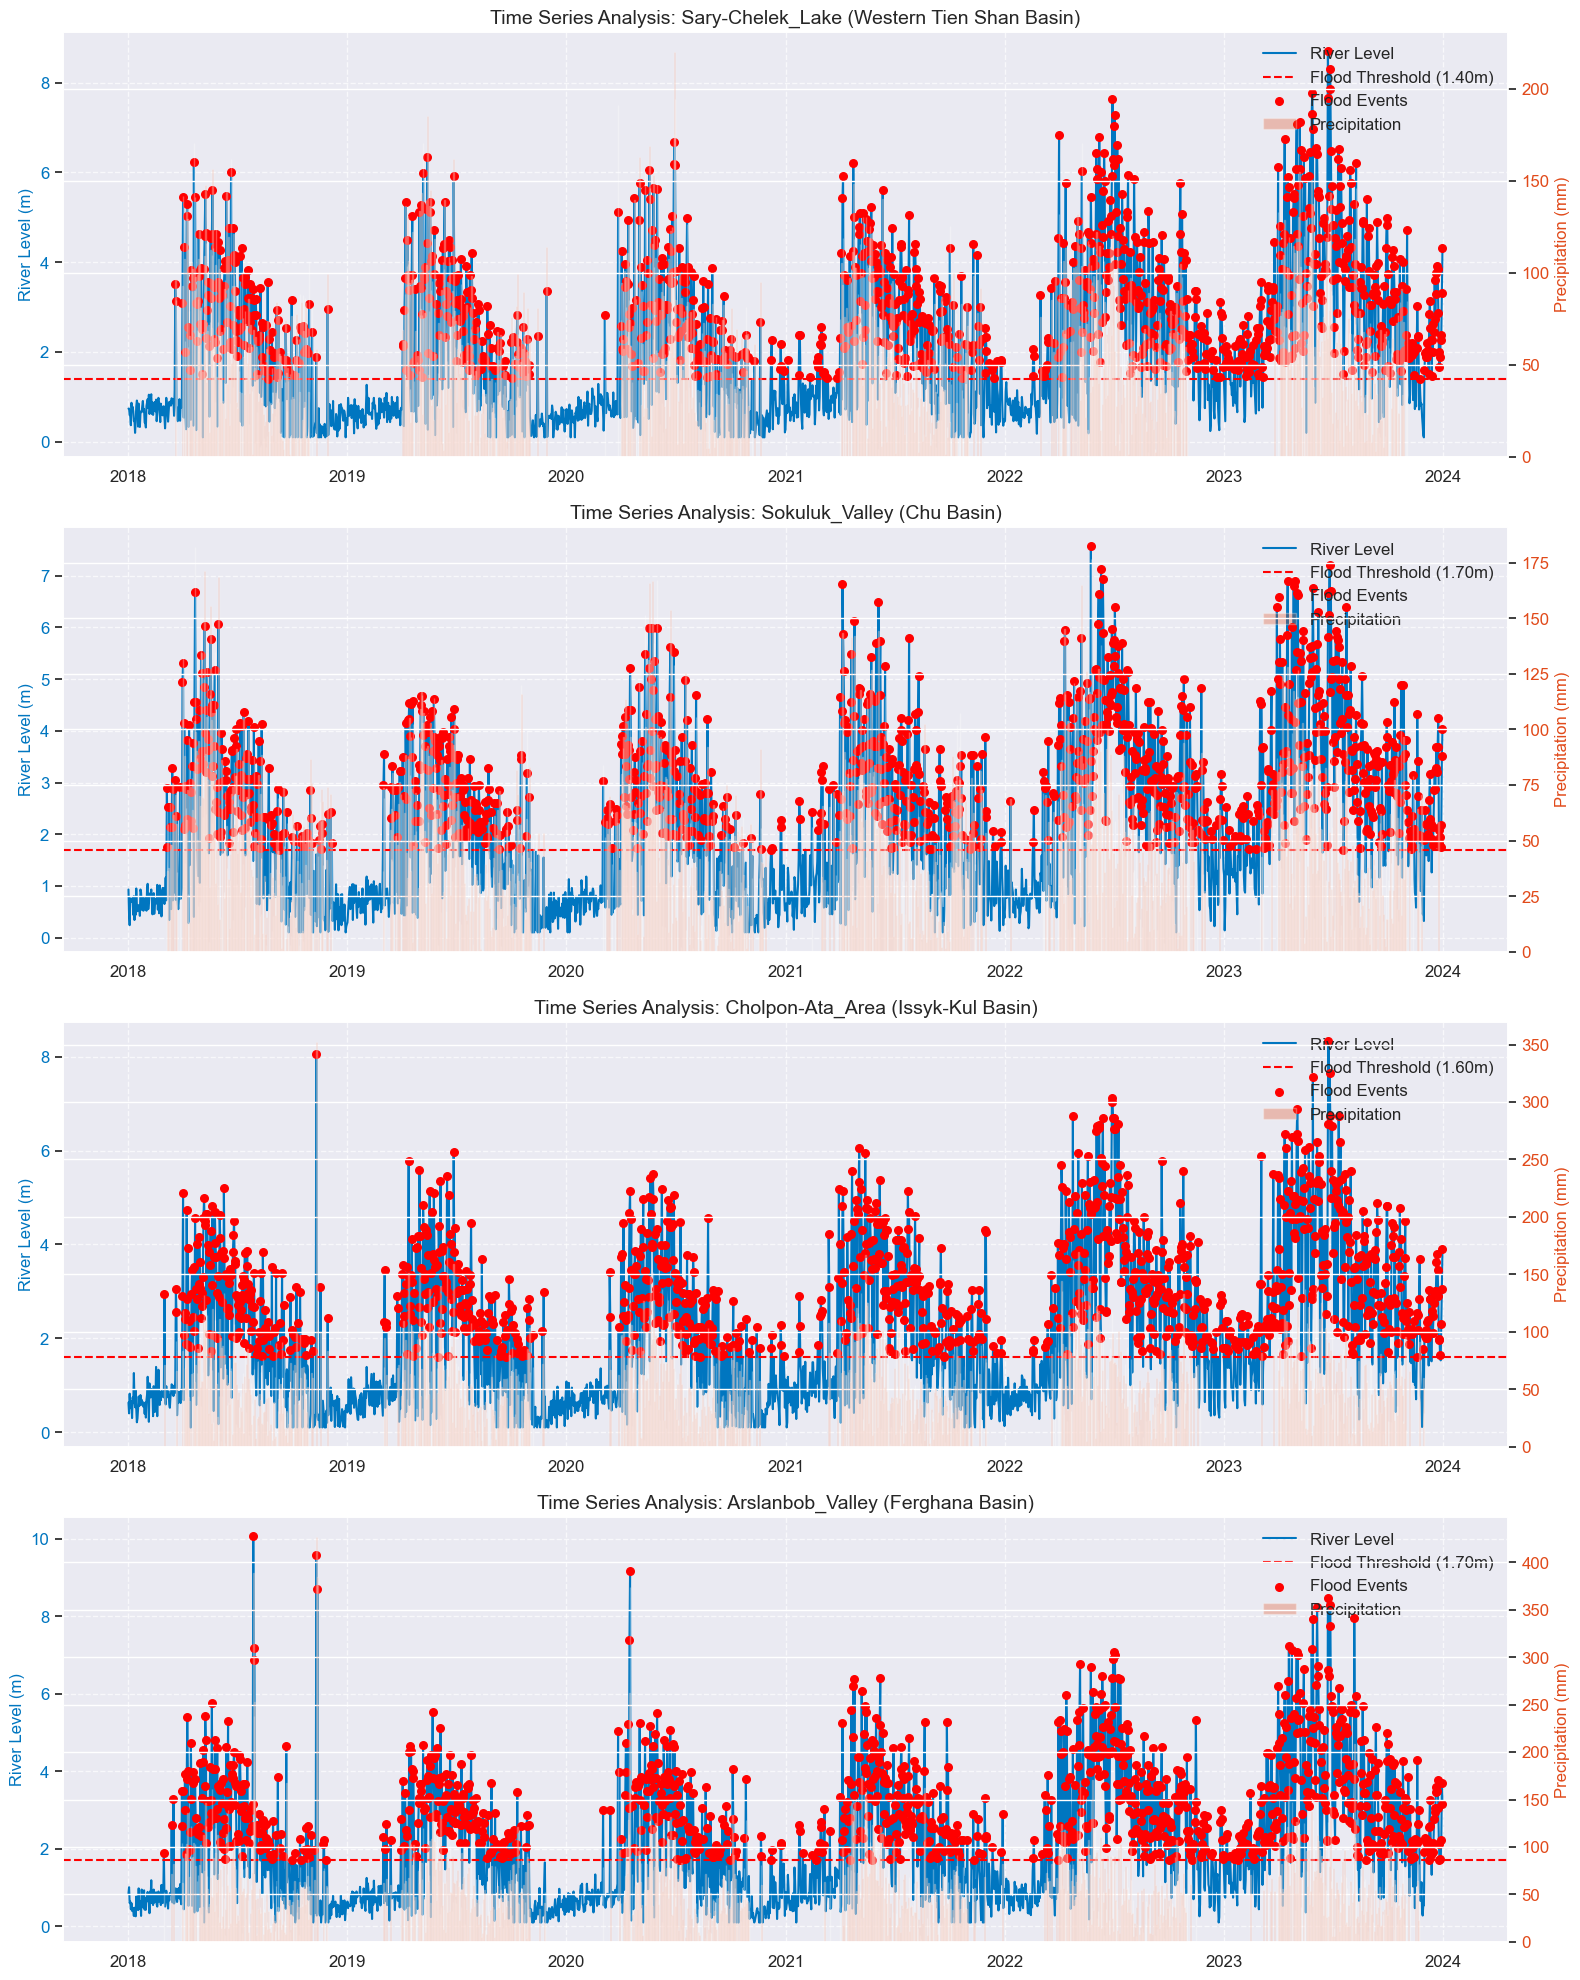

<Figure size 1400x1200 with 0 Axes>

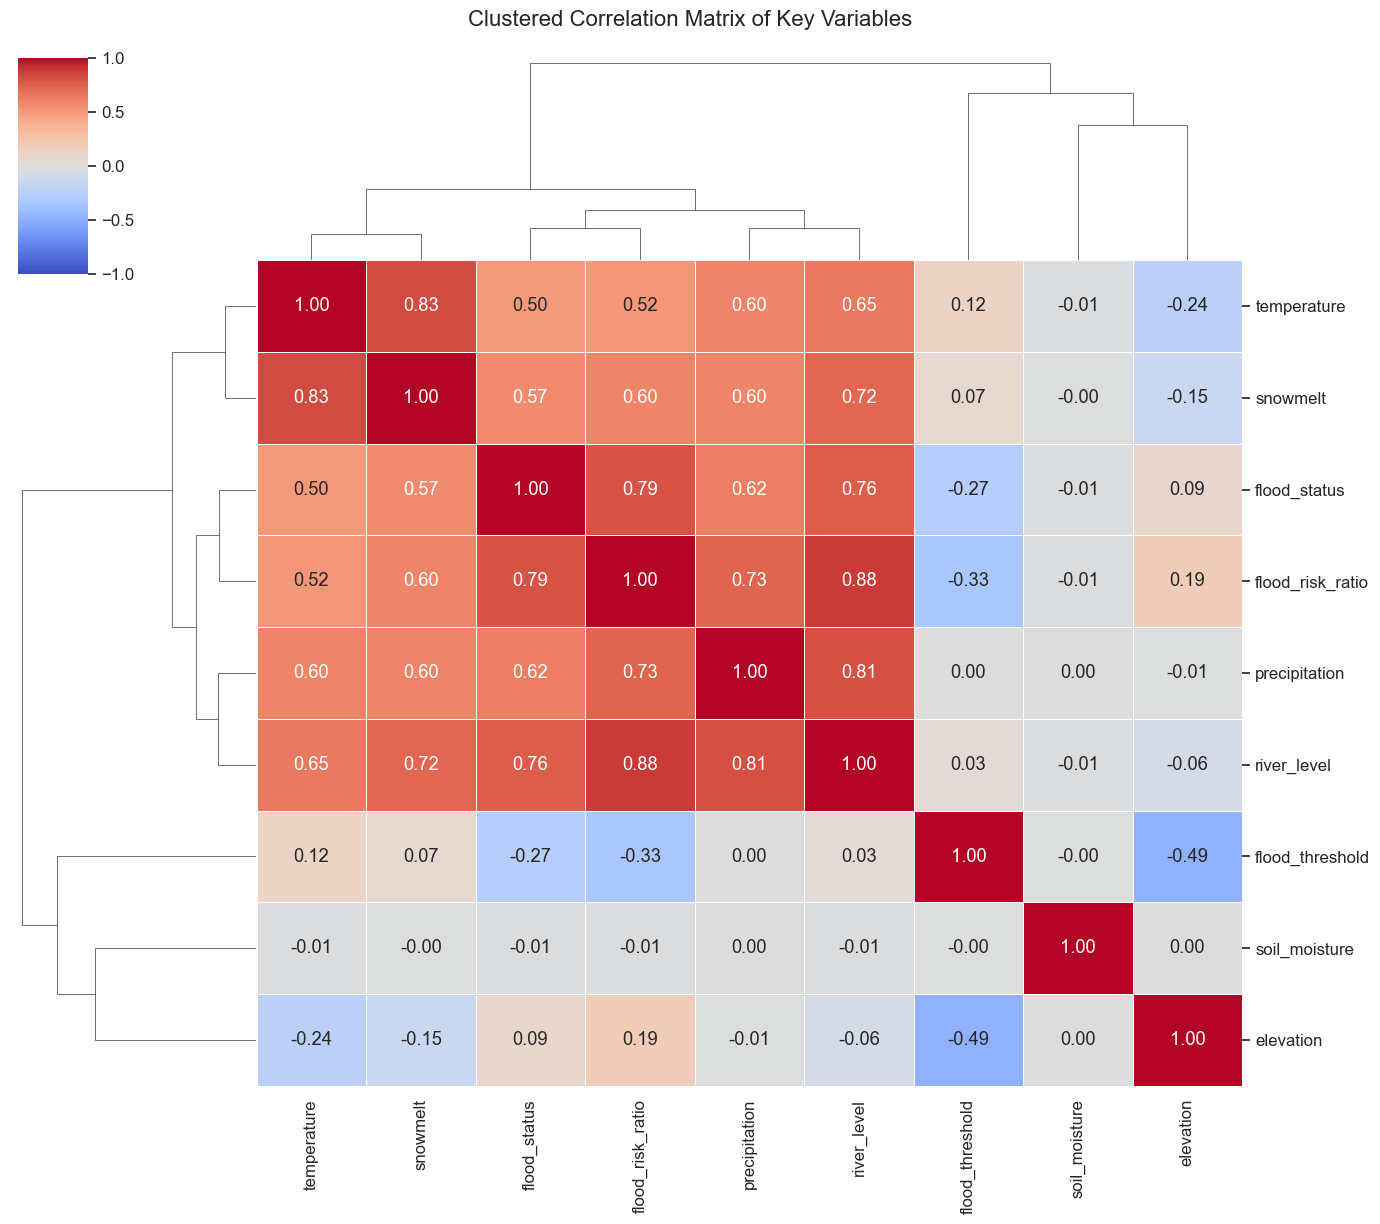

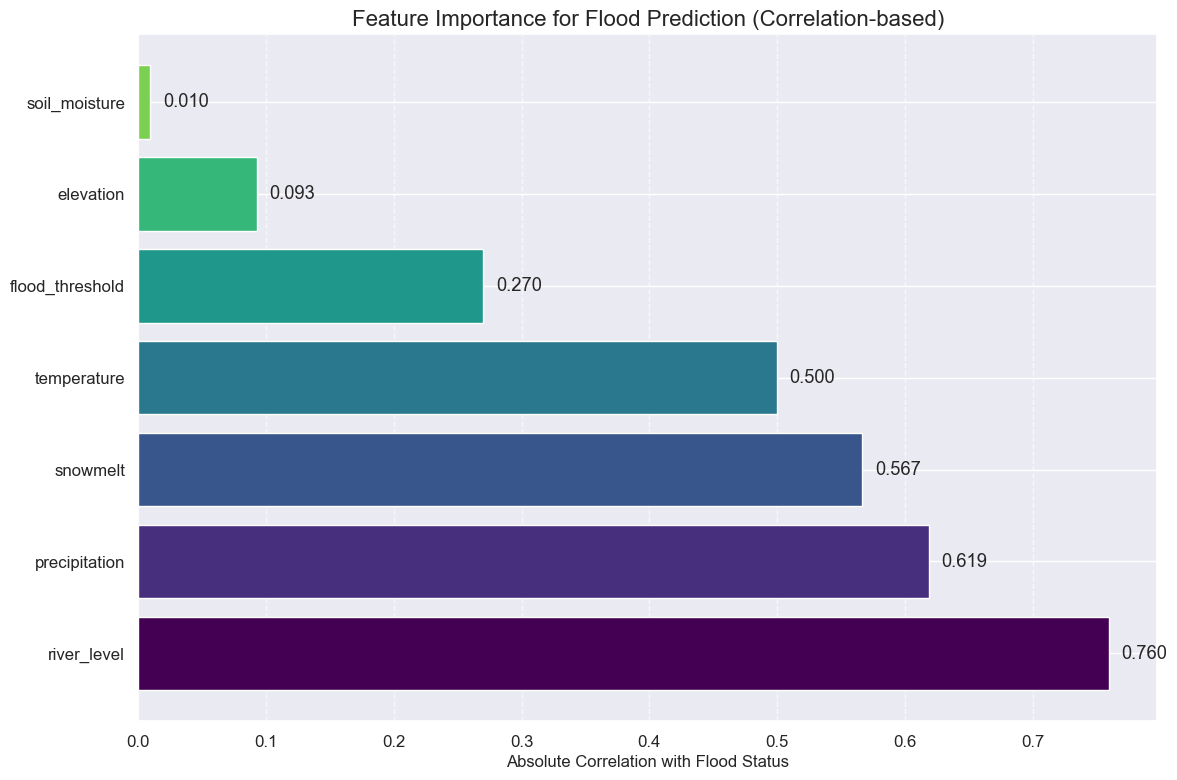

<Figure size 1800x1000 with 0 Axes>

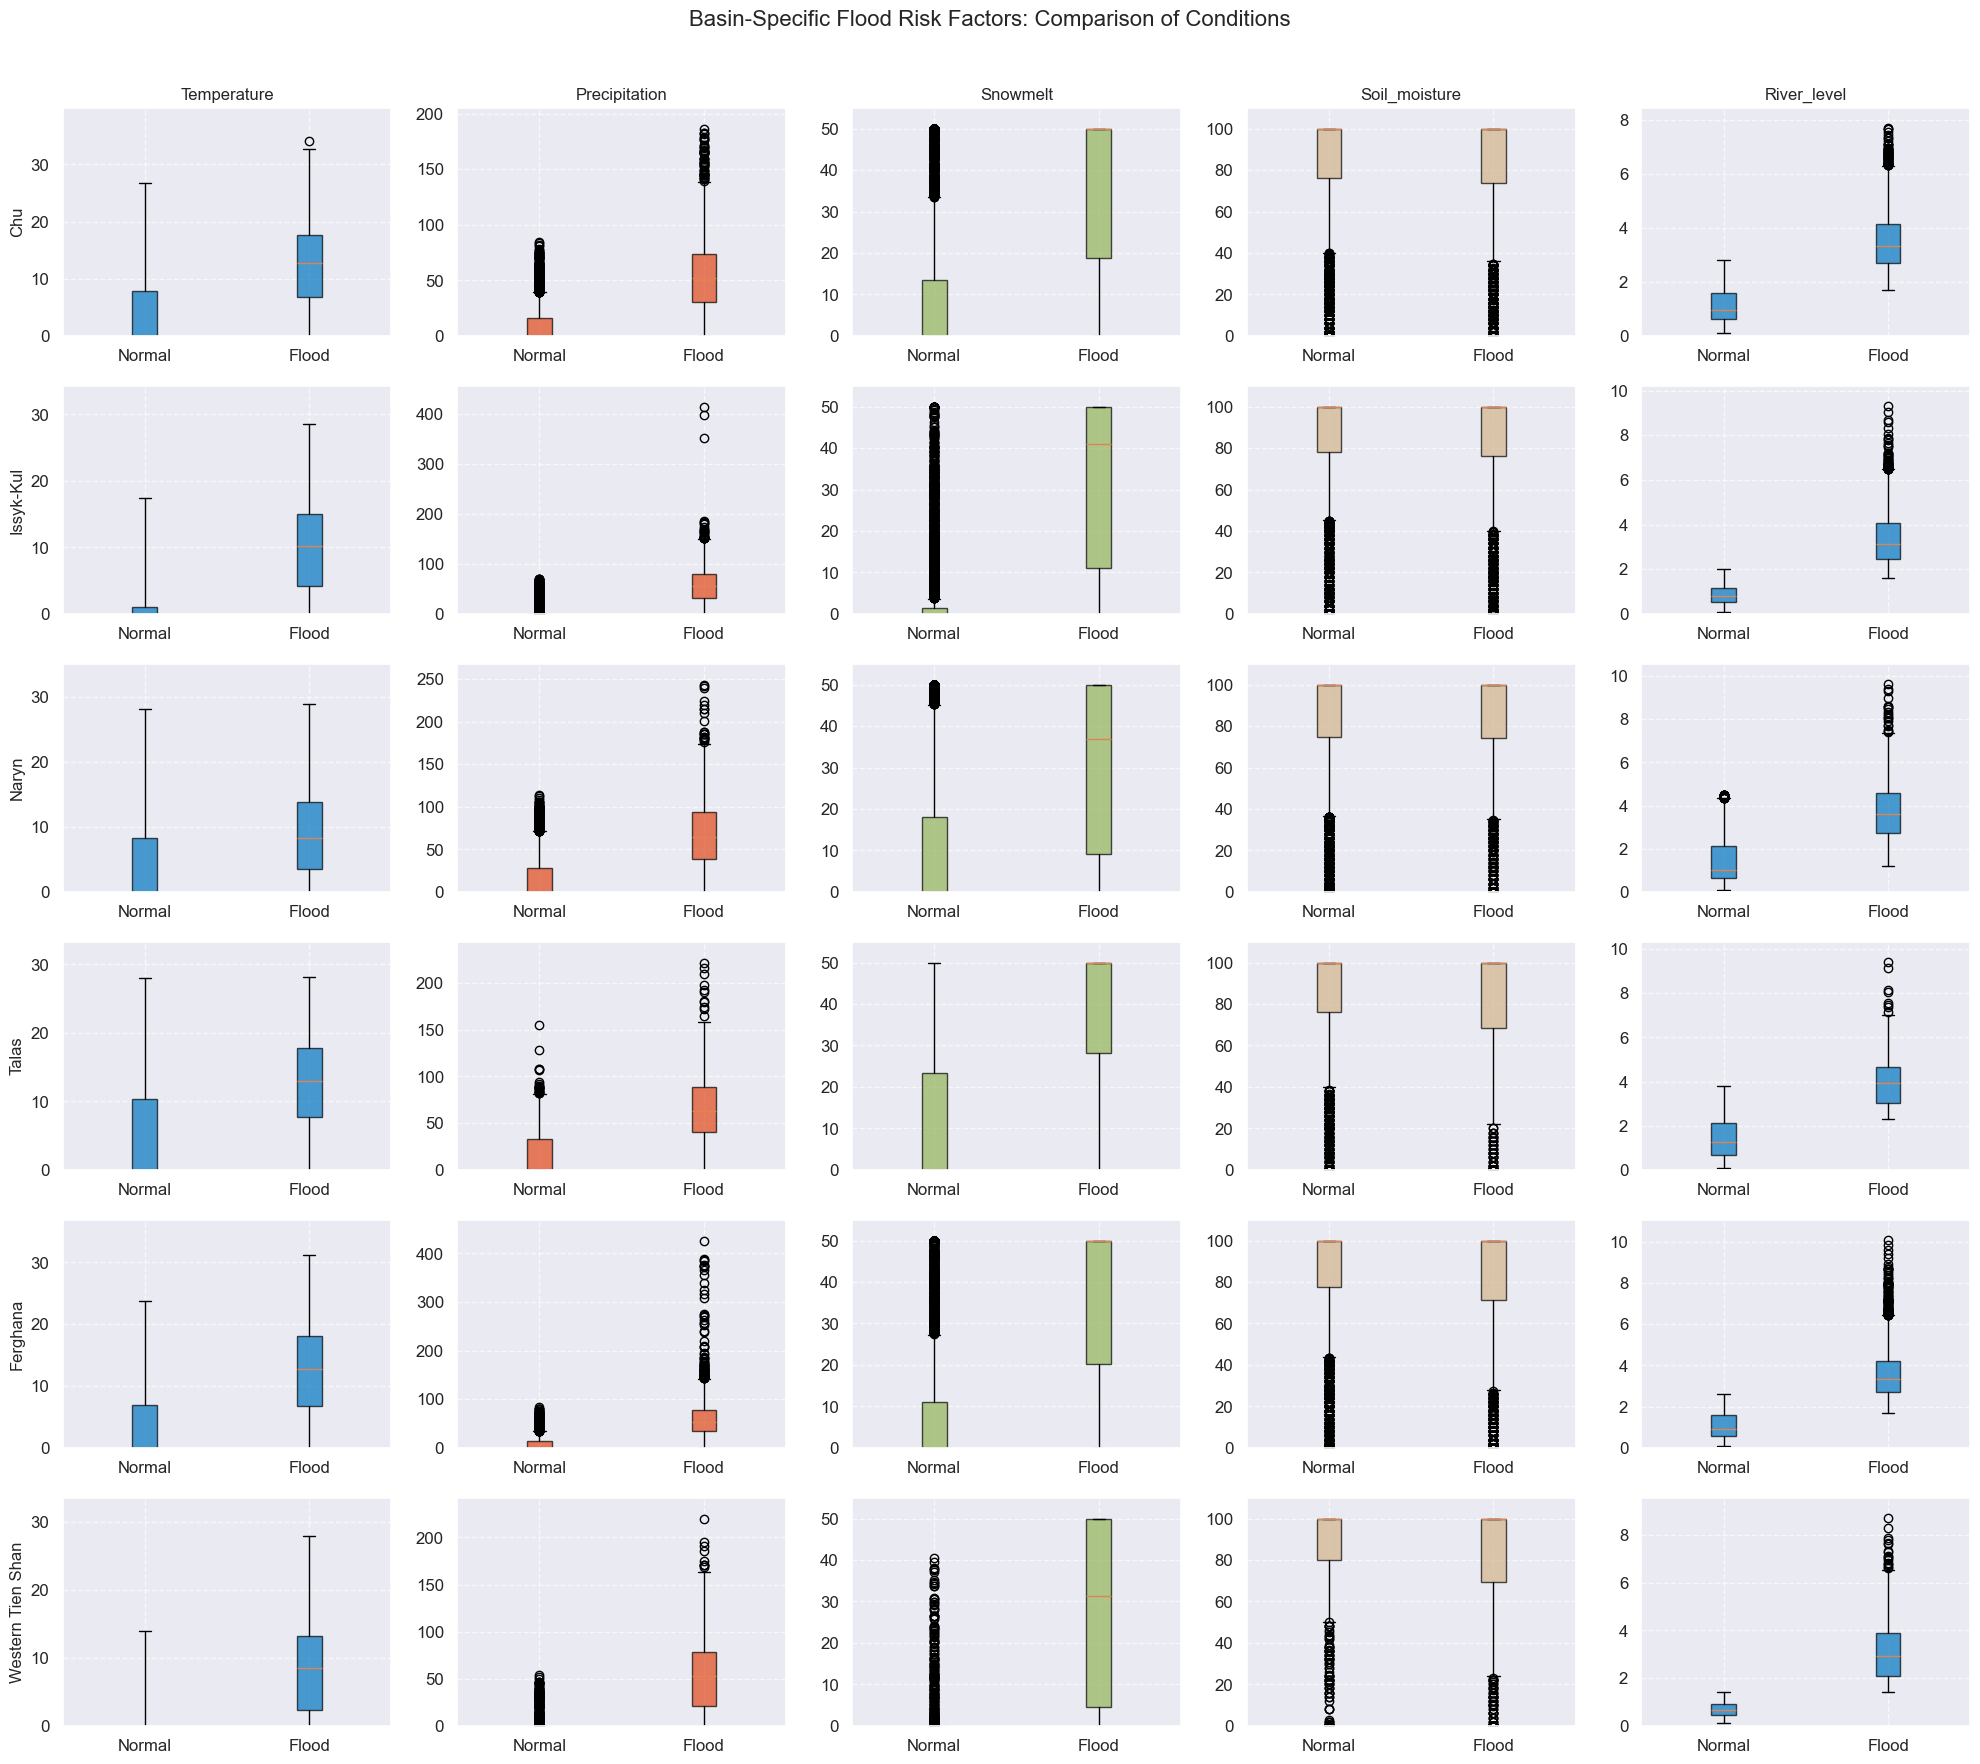

<Figure size 1400x800 with 0 Axes>

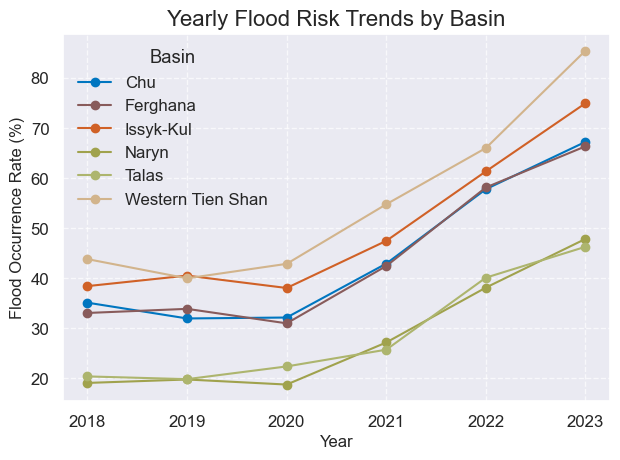

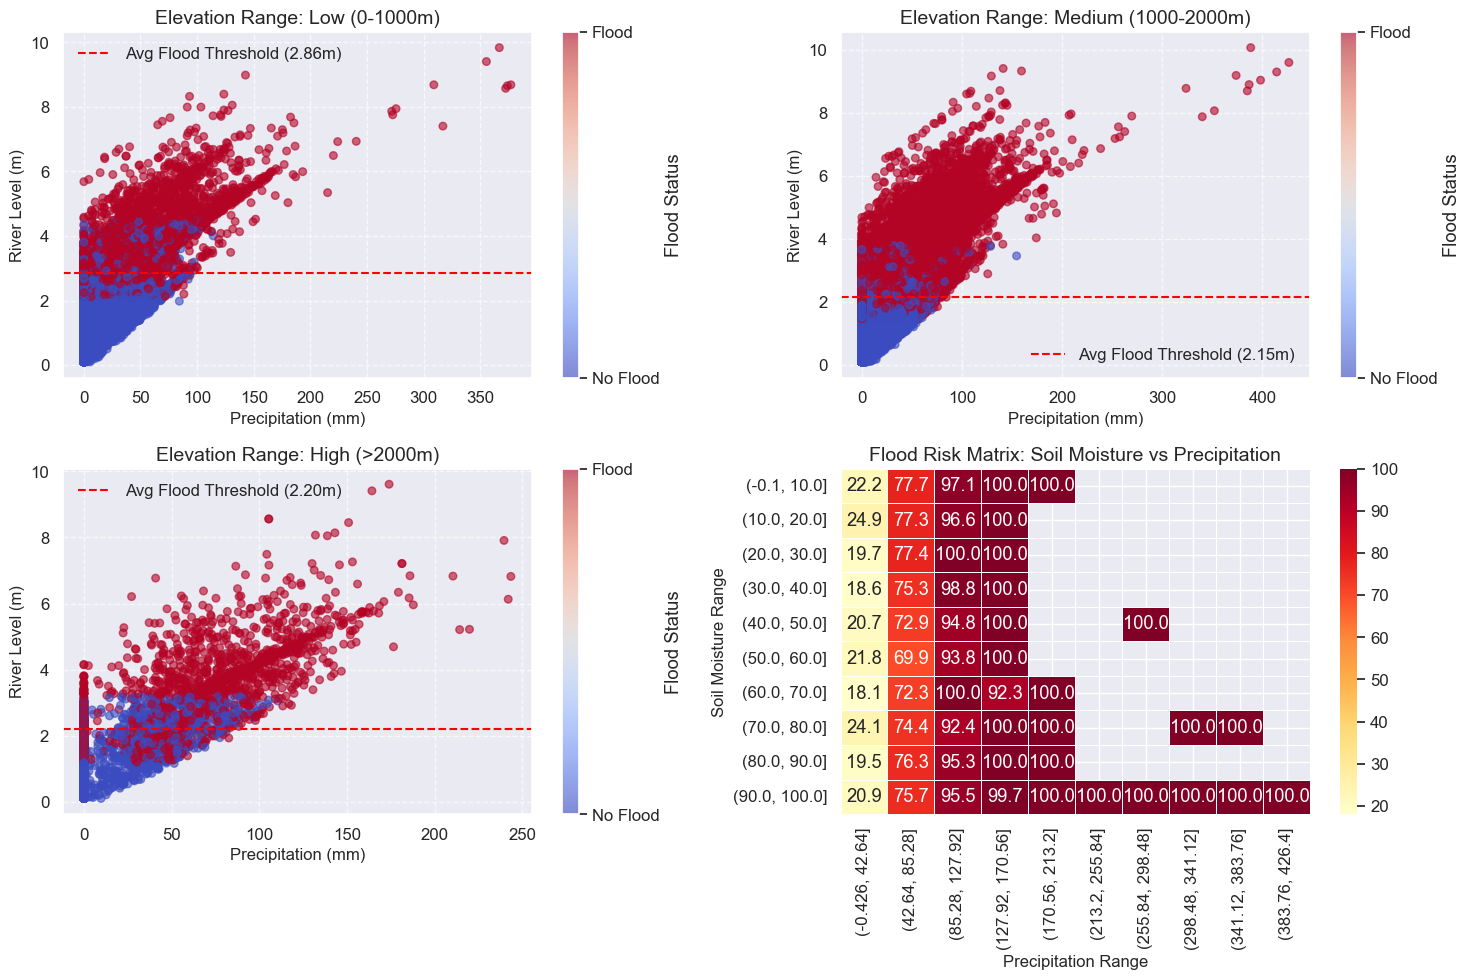

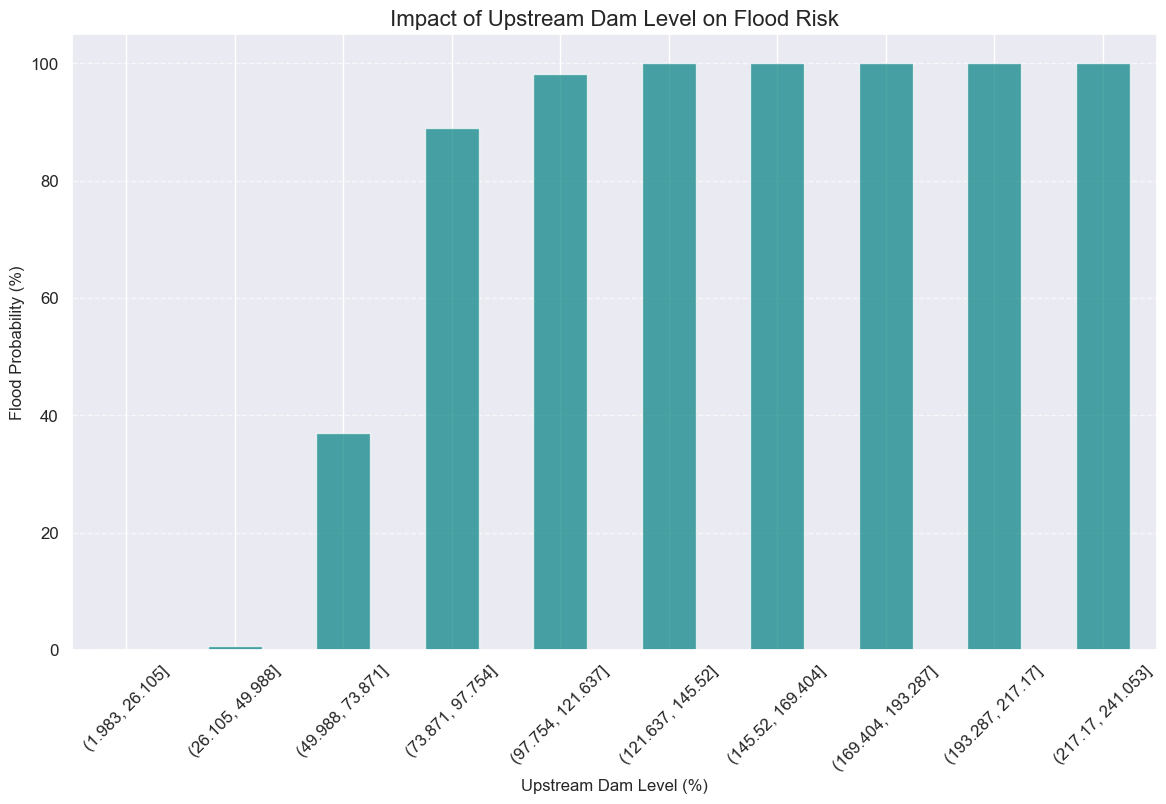

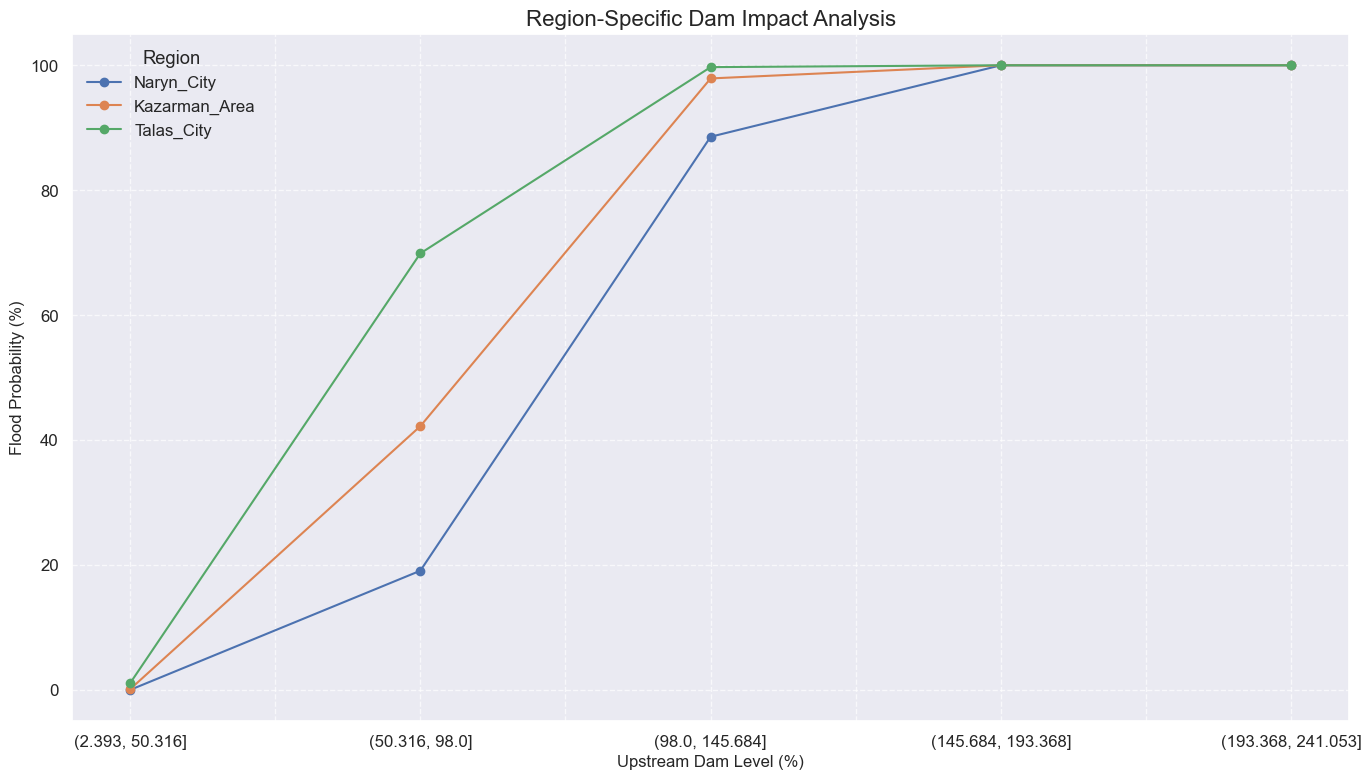

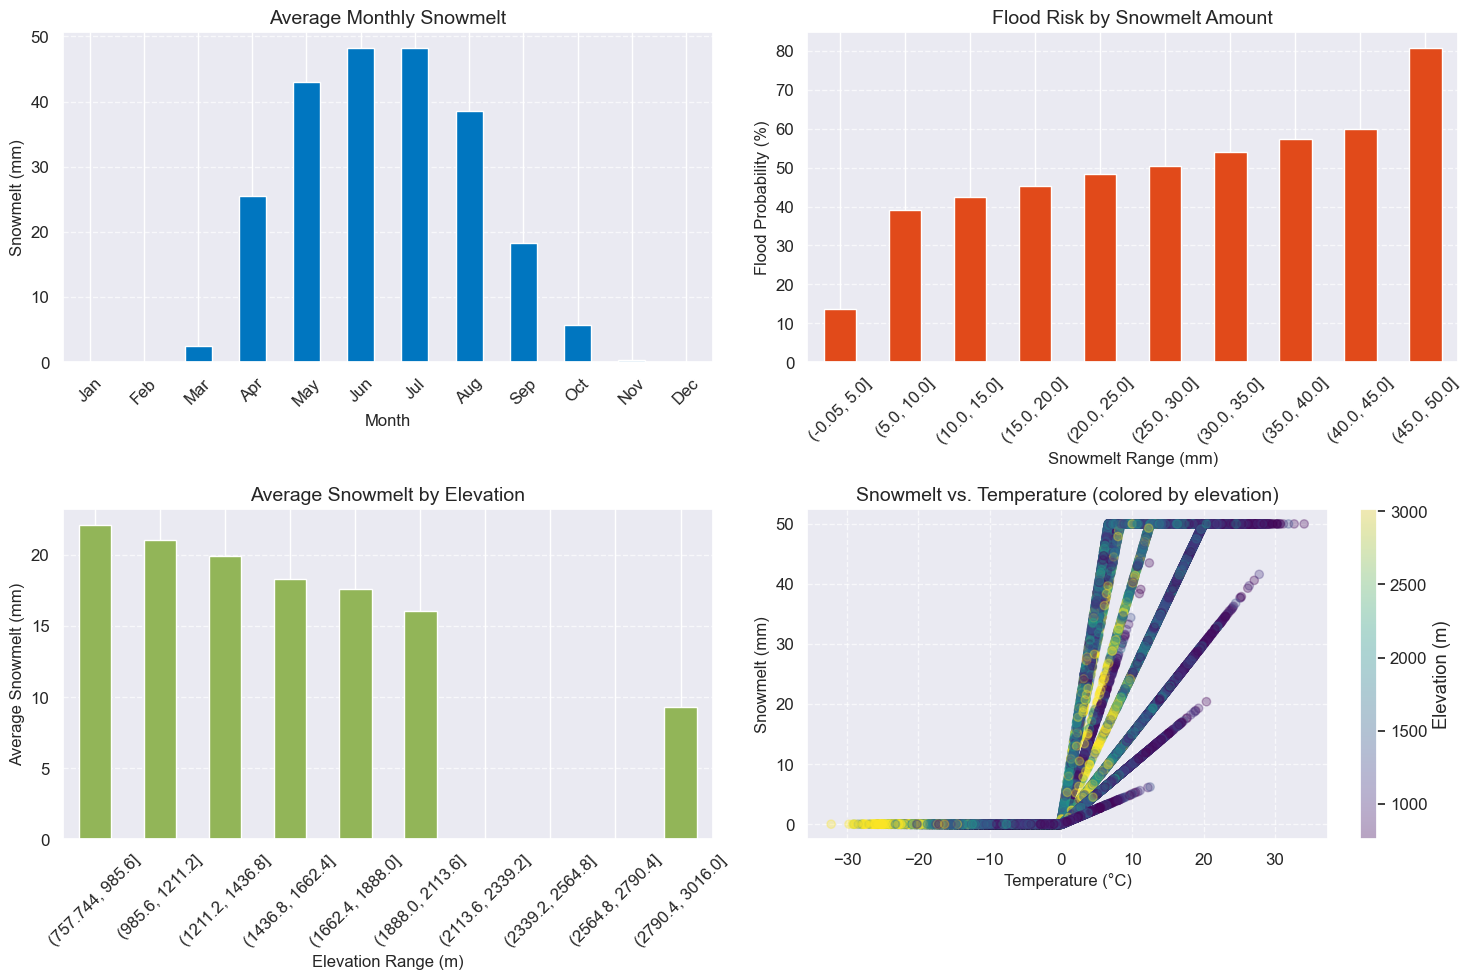

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator
import matplotlib.dates as mdates

# Set style and create output directory
plt.style.use('seaborn-v0_8-whitegrid')
sns.set(font_scale=1.1)
if not os.path.exists('visualizations'):
    os.makedirs('visualizations')

# Load the dataset
print("Loading data...")
df = pd.read_csv('kyrgyzstan_flood_data.csv')
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
# Create seasons using a mapping approach
season_map = {
    1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall',
    12: 'Winter'
}
df['season'] = df['month'].map(season_map)

# Create a flood risk ratio
df['flood_risk_ratio'] = df['river_level'] / df['flood_threshold']

# Custom colormap for Kyrgyzstan-themed visualizations
kyrgyz_colors = ['#0076c0', '#E14A1A', '#92B558', '#D2B48C']
kyrgyz_cmap = LinearSegmentedColormap.from_list('kyrgyz', kyrgyz_colors, N=100)

print("Creating visualizations...")

# 1. Geographic Flood Risk Map (simplified representation)
plt.figure(figsize=(14, 10))

# Group data by region and calculate flood risk statistics
region_stats = df.groupby('region').agg({
    'flood_status': 'mean',
    'elevation': 'mean',
    'flood_threshold': 'mean',
    'river_level': 'mean',
    'basin': 'first'
}).reset_index()

# Calculate flood risk percentage
region_stats['flood_risk_percent'] = region_stats['flood_status'] * 100
region_stats = region_stats.sort_values('flood_risk_percent', ascending=False)

# Create horizontal bar chart by basin (as a geographic approximation)
basins = region_stats['basin'].unique()
colors = plt.cm.viridis(np.linspace(0, 1, len(basins)))
basin_color_map = dict(zip(basins, colors))

plt.figure(figsize=(14, 10))
for i, basin in enumerate(basins):
    basin_data = region_stats[region_stats['basin'] == basin]
    plt.barh(basin_data['region'], basin_data['flood_risk_percent'], 
             color=[basin_color_map[basin]] * len(basin_data),
             alpha=0.7, label=basin if i == 0 else "")
    
    # Add risk percentage labels
    for j, (region, risk) in enumerate(zip(basin_data['region'], basin_data['flood_risk_percent'])):
        plt.text(risk + 0.1, region, f"{risk:.1f}%", va='center')

plt.xlabel('Flood Risk (%)', fontsize=12)
plt.ylabel('Region', fontsize=12)
plt.title('Regional Flood Risk Map of Kyrgyzstan', fontsize=16)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Create a custom legend for basins
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=basin_color_map[basin], label=basin, alpha=0.7) for basin in basins]
plt.legend(handles=legend_elements, title='Basin', loc='lower right')

plt.tight_layout()
plt.savefig('visualizations/regional_flood_risk_map.png', dpi=300, bbox_inches='tight')

# 2. Seasonal Patterns and Flood Risk Dashboard
plt.figure(figsize=(20, 15))

# Create a 2x3 subplot grid
plt.subplot(2, 3, 1)
monthly_flood_rate = df.groupby('month')['flood_status'].mean() * 100
monthly_flood_rate.plot(kind='bar', color=kyrgyz_colors[0])
plt.title('Monthly Flood Occurrence Rate', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Flood Rate (%)', fontsize=12)
plt.xticks(range(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(2, 3, 2)
seasonal_vars = df.groupby('month').agg({
    'temperature': 'mean',
    'precipitation': 'mean',
    'snowmelt': 'mean'
}).reset_index()

# Multiple line plot for seasonal variables
ax1 = plt.gca()
ax1.plot(seasonal_vars['month'], seasonal_vars['temperature'], 'o-', color=kyrgyz_colors[0], label='Temperature (°C)')
ax1.set_ylabel('Temperature (°C)', color=kyrgyz_colors[0], fontsize=12)
ax1.tick_params(axis='y', labelcolor=kyrgyz_colors[0])

ax2 = ax1.twinx()
ax2.plot(seasonal_vars['month'], seasonal_vars['precipitation'], 's-', color=kyrgyz_colors[1], label='Precipitation (mm)')
ax2.plot(seasonal_vars['month'], seasonal_vars['snowmelt'], '^-', color=kyrgyz_colors[2], label='Snowmelt (mm)')
ax2.set_ylabel('Precipitation/Snowmelt (mm)', color=kyrgyz_colors[1], fontsize=12)
ax2.tick_params(axis='y', labelcolor=kyrgyz_colors[1])

ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
plt.title('Seasonal Climate Variables', fontsize=14)
plt.grid(linestyle='--', alpha=0.7)

# Create a unified legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.subplot(2, 3, 3)
# River level seasonality by basin
season_basin_level = df.groupby(['basin', 'month'])['river_level'].mean().unstack()
season_basin_level.plot(marker='o', cmap=kyrgyz_cmap)
plt.title('River Level Seasonality by Basin', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average River Level (m)', fontsize=12)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
plt.grid(linestyle='--', alpha=0.7)
plt.legend(title='Basin')

plt.subplot(2, 3, 4)
# Elevation vs. Flood Risk analysis
elevation_bins = pd.cut(df['elevation'], bins=10)
elevation_flood = df.groupby(elevation_bins)['flood_status'].mean() * 100
elevation_flood.plot(kind='bar', color=kyrgyz_colors[3])
plt.title('Flood Risk by Elevation', fontsize=14)
plt.xlabel('Elevation Range (m)', fontsize=12)
plt.ylabel('Flood Rate (%)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(2, 3, 5)
# Soil moisture vs flood risk
soil_moisture_bins = pd.cut(df['soil_moisture'], bins=10)
soil_moisture_flood = df.groupby(soil_moisture_bins)['flood_status'].mean() * 100
soil_moisture_flood.plot(kind='bar', color=kyrgyz_colors[2])
plt.title('Flood Risk by Soil Moisture', fontsize=14)
plt.xlabel('Soil Moisture Range (%)', fontsize=12)
plt.ylabel('Flood Rate (%)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(2, 3, 6)
# Distribution of flood risk ratio
plt.hist(df['flood_risk_ratio'], bins=50, color=kyrgyz_colors[1], alpha=0.7)
plt.axvline(x=1.0, color='red', linestyle='--', label='Flood Threshold')
plt.title('Distribution of Flood Risk Ratio', fontsize=14)
plt.xlabel('River Level / Flood Threshold', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.savefig('visualizations/seasonal_flood_risk_dashboard.png', dpi=300, bbox_inches='tight')

# 3. Time Series Analysis for High-Risk Areas
plt.figure(figsize=(16, 20))

# Find top 4 regions with highest flood occurrence
top_regions = df.groupby('region')['flood_status'].mean().sort_values(ascending=False).head(4).index

for i, region in enumerate(top_regions):
    region_data = df[df['region'] == region].sort_values('date')
    
    # Create a multi-panel plot for each region
    plt.subplot(4, 1, i+1)
    
    # River level and threshold
    ax1 = plt.gca()
    ax1.plot(region_data['date'], region_data['river_level'], '-', color=kyrgyz_colors[0], label='River Level')
    ax1.axhline(y=region_data['flood_threshold'].iloc[0], color='red', linestyle='--', 
               label=f'Flood Threshold ({region_data["flood_threshold"].iloc[0]:.2f}m)')
    
    # Highlight flood events
    flood_events = region_data[region_data['flood_status'] == 1]
    if len(flood_events) > 0:
        ax1.scatter(flood_events['date'], flood_events['river_level'], 
                  color='red', s=30, zorder=5, label='Flood Events')
    
    ax1.set_ylabel('River Level (m)', color=kyrgyz_colors[0], fontsize=12)
    ax1.tick_params(axis='y', labelcolor=kyrgyz_colors[0])
    
    # Add precipitation on secondary axis
    ax2 = ax1.twinx()
    ax2.bar(region_data['date'], region_data['precipitation'], 
           alpha=0.3, color=kyrgyz_colors[1], label='Precipitation')
    ax2.set_ylabel('Precipitation (mm)', color=kyrgyz_colors[1], fontsize=12)
    ax2.tick_params(axis='y', labelcolor=kyrgyz_colors[1])
    
    # Format x-axis
    ax1.xaxis.set_major_locator(mdates.YearLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    
    # Title and grid
    plt.title(f'Time Series Analysis: {region} ({region_data["basin"].iloc[0]} Basin)', fontsize=14)
    ax1.grid(linestyle='--', alpha=0.7)
    
    # Create a unified legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig('visualizations/high_risk_regions_time_series.png', dpi=300, bbox_inches='tight')

# 4. Correlation Heatmap with Clustered Variables
plt.figure(figsize=(14, 12))

# Select relevant columns for correlation analysis
corr_cols = ['temperature', 'precipitation', 'snowmelt', 'river_level', 
             'flood_threshold', 'soil_moisture', 'elevation', 'flood_status', 'flood_risk_ratio']
corr = df[corr_cols].corr()

# Generate clustered heatmap
sns.clustermap(corr, cmap='coolwarm', annot=True, fmt='.2f',
               linewidths=0.5, figsize=(14, 12), vmin=-1, vmax=1)
plt.suptitle('Clustered Correlation Matrix of Key Variables', fontsize=16, y=1.02)
plt.savefig('visualizations/correlation_heatmap_clustered.png', dpi=300, bbox_inches='tight')

# 5. Feature Importance for Flood Prediction (Using simple correlation-based approach)
plt.figure(figsize=(12, 8))

# Calculate absolute correlation with flood status
feature_importance = corr['flood_status'].abs().sort_values(ascending=False)
feature_importance = feature_importance.drop('flood_status')  # Remove self-correlation
feature_importance = feature_importance.drop('flood_risk_ratio')  # Remove direct derivative

# Plot feature importance
bars = plt.barh(feature_importance.index, feature_importance.values, color=plt.cm.viridis(np.linspace(0, 0.8, len(feature_importance))))
plt.title('Feature Importance for Flood Prediction (Correlation-based)', fontsize=16)
plt.xlabel('Absolute Correlation with Flood Status', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add correlation values on bars
for i, v in enumerate(feature_importance.values):
    plt.text(v + 0.01, i, f"{v:.3f}", va='center')

plt.tight_layout()
plt.savefig('visualizations/feature_importance.png', dpi=300, bbox_inches='tight')

# 6. Basin-Specific Flood Risk Factors
plt.figure(figsize=(18, 10))

# For each basin, compare key variables during flood vs. non-flood conditions
basins = df['basin'].unique()
num_basins = len(basins)
variables = ['temperature', 'precipitation', 'snowmelt', 'soil_moisture', 'river_level']
num_vars = len(variables)

# Create a grid of subplots (basins x variables)
fig, axes = plt.subplots(num_basins, num_vars, figsize=(num_vars*4, num_basins*3))

for i, basin in enumerate(basins):
    basin_data = df[df['basin'] == basin]
    flood_data = basin_data[basin_data['flood_status'] == 1]
    normal_data = basin_data[basin_data['flood_status'] == 0]
    
    for j, var in enumerate(variables):
        ax = axes[i, j]
        
        # Create boxplots
        ax.boxplot([normal_data[var], flood_data[var]], 
                  labels=['Normal', 'Flood'], 
                  patch_artist=True,
                  boxprops=dict(facecolor=kyrgyz_colors[j % len(kyrgyz_colors)], alpha=0.7))
        
        # Set titles and labels
        if i == 0:  # Only for the top row
            ax.set_title(var.capitalize(), fontsize=12)
        
        if j == 0:  # Only for the leftmost column
            ax.set_ylabel(basin, fontsize=12)
            
        # Set y-limit to better visualize differences
        if len(flood_data) > 0:  # Only if there's flood data
            combined_data = pd.concat([normal_data[var], flood_data[var]])
            data_min, data_max = combined_data.min(), combined_data.max()
            data_range = data_max - data_min
            ax.set_ylim([max(0, data_min - 0.1 * data_range), data_max + 0.1 * data_range])
        
        ax.grid(linestyle='--', alpha=0.7)

plt.suptitle('Basin-Specific Flood Risk Factors: Comparison of Conditions', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])  # Adjust for suptitle
plt.savefig('visualizations/basin_specific_flood_factors.png', dpi=300, bbox_inches='tight')

# 7. Temporal trends in flood risk
plt.figure(figsize=(14, 8))

# Calculate yearly flood statistics
yearly_stats = df.groupby(['year', 'basin'])['flood_status'].mean().unstack() * 100

# Plot yearly trends by basin
yearly_stats.plot(marker='o', cmap=kyrgyz_cmap)
plt.title('Yearly Flood Risk Trends by Basin', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Flood Occurrence Rate (%)', fontsize=12)
plt.grid(linestyle='--', alpha=0.7)
plt.legend(title='Basin')
plt.xticks(df['year'].unique())

plt.tight_layout()
plt.savefig('visualizations/yearly_flood_trends.png', dpi=300, bbox_inches='tight')

# 8. Interactive Threshold Analysis (3D-like representation in 2D)
plt.figure(figsize=(15, 10))

# Create multiple panels for different elevation ranges
elevation_ranges = ['Low (0-1000m)', 'Medium (1000-2000m)', 'High (>2000m)']
elevation_bins = [0, 1000, 2000, 4000]
colors = [kyrgyz_colors[0], kyrgyz_colors[1], kyrgyz_colors[2]]

for i in range(len(elevation_ranges)):
    plt.subplot(2, 2, i+1)
    
    # Filter data by elevation range
    range_data = df[(df['elevation'] >= elevation_bins[i]) & (df['elevation'] < elevation_bins[i+1])]
    
    # Create precipitation vs. river level scatterplot
    scatter = plt.scatter(range_data['precipitation'], range_data['river_level'], 
                          c=range_data['flood_status'], cmap='coolwarm', alpha=0.6, s=30)
    
    # Add threshold line (average for this elevation range)
    avg_threshold = range_data['flood_threshold'].mean()
    plt.axhline(y=avg_threshold, color='red', linestyle='--', 
                label=f'Avg Flood Threshold ({avg_threshold:.2f}m)')
    
    plt.title(f'Elevation Range: {elevation_ranges[i]}', fontsize=14)
    plt.xlabel('Precipitation (mm)', fontsize=12)
    plt.ylabel('River Level (m)', fontsize=12)
    plt.grid(linestyle='--', alpha=0.7)
    plt.legend()
    
    # Add colorbar to indicate flood status
    cbar = plt.colorbar(scatter)
    cbar.set_label('Flood Status')
    cbar.set_ticks([0, 1])
    cbar.set_ticklabels(['No Flood', 'Flood'])

# Add a fourth subplot summarizing flood risk factors
plt.subplot(2, 2, 4)
# Create risk matrix: precipitation vs soil moisture with flood frequency
pivot = pd.pivot_table(df, values='flood_status', 
                       index=pd.cut(df['soil_moisture'], bins=10), 
                       columns=pd.cut(df['precipitation'], bins=10),
                       aggfunc='mean')

# Plot heatmap
sns.heatmap(pivot * 100, cmap='YlOrRd', annot=True, fmt='.1f', linewidths=0.5)
plt.title('Flood Risk Matrix: Soil Moisture vs Precipitation', fontsize=14)
plt.xlabel('Precipitation Range', fontsize=12)
plt.ylabel('Soil Moisture Range', fontsize=12)

plt.tight_layout()
plt.savefig('visualizations/threshold_analysis.png', dpi=300, bbox_inches='tight')

# 9. Dam Impact Analysis
plt.figure(figsize=(14, 8))

# Filter regions with upstream dam influence
dam_regions = df[df['upstream_dam_level'].notna() & (df['upstream_dam_level'] > 0)]
dam_regions_list = dam_regions['region'].unique()

if len(dam_regions_list) > 0:
    # Group data by upstream dam level and calculate flood probability
    dam_level_bins = pd.cut(dam_regions['upstream_dam_level'], bins=10)
    dam_impact = dam_regions.groupby(dam_level_bins)['flood_status'].mean() * 100
    
    # Plot the relationship
    dam_impact.plot(kind='bar', color='teal', alpha=0.7)
    plt.title('Impact of Upstream Dam Level on Flood Risk', fontsize=16)
    plt.xlabel('Upstream Dam Level (%)', fontsize=12)
    plt.ylabel('Flood Probability (%)', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45)
    
    # Add region-specific lines
    plt.figure(figsize=(14, 8))
    for region in dam_regions_list:
        region_data = dam_regions[dam_regions['region'] == region]
        region_bins = pd.cut(region_data['upstream_dam_level'], bins=5)
        region_impact = region_data.groupby(region_bins)['flood_status'].mean() * 100
        region_impact.plot(label=region, marker='o')
    
    plt.title('Region-Specific Dam Impact Analysis', fontsize=16)
    plt.xlabel('Upstream Dam Level (%)', fontsize=12)
    plt.ylabel('Flood Probability (%)', fontsize=12)
    plt.grid(linestyle='--', alpha=0.7)
    plt.legend(title='Region')
else:
    plt.text(0.5, 0.5, 'No regions with upstream dam influence found in the dataset', 
             horizontalalignment='center', verticalalignment='center', fontsize=14)

plt.tight_layout()
plt.savefig('visualizations/dam_impact_analysis.png', dpi=300, bbox_inches='tight')

# 10. Snowmelt Contribution Analysis
plt.figure(figsize=(15, 10))

# Panel 1: Seasonal snowmelt patterns
plt.subplot(2, 2, 1)
monthly_snowmelt = df.groupby('month')['snowmelt'].mean()
monthly_snowmelt.plot(kind='bar', color=kyrgyz_colors[0])
plt.title('Average Monthly Snowmelt', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Snowmelt (mm)', fontsize=12)
plt.xticks(range(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Panel 2: Snowmelt vs. Flood Risk
plt.subplot(2, 2, 2)
snowmelt_bins = pd.cut(df['snowmelt'], bins=10)
snowmelt_flood = df.groupby(snowmelt_bins)['flood_status'].mean() * 100
snowmelt_flood.plot(kind='bar', color=kyrgyz_colors[1])
plt.title('Flood Risk by Snowmelt Amount', fontsize=14)
plt.xlabel('Snowmelt Range (mm)', fontsize=12)
plt.ylabel('Flood Probability (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)

# Panel 3: Elevation vs. Snowmelt
plt.subplot(2, 2, 3)
elevation_bins = pd.cut(df['elevation'], bins=10)
elevation_snowmelt = df.groupby(elevation_bins)['snowmelt'].mean()
elevation_snowmelt.plot(kind='bar', color=kyrgyz_colors[2])
plt.title('Average Snowmelt by Elevation', fontsize=14)
plt.xlabel('Elevation Range (m)', fontsize=12)
plt.ylabel('Average Snowmelt (mm)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)

# Panel 4: Snowmelt Contribution vs Temperature
plt.subplot(2, 2, 4)
plt.scatter(df['temperature'], df['snowmelt'], alpha=0.3, c=df['elevation'], cmap='viridis')
plt.title('Snowmelt vs. Temperature (colored by elevation)', fontsize=14)
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Snowmelt (mm)', fontsize=12)
plt.grid(linestyle='--', alpha=0.7)
plt.colorbar(label='Elevation (m)')

plt.tight_layout()
plt.savefig('visualizations/snowmelt_analysis.png', dpi=300, bbox_inches='tight')

print("Visualizations complete! All plots saved to 'visualizations' directory.")